# Pertemuan 13 - Deep Learning dan NLP Dasar

**Nama:** Nabil Fakhrezy  
**NIM:** 240401010286  
**Kelas:** IF401  
**Program Studi:** PJJ Informatika

## Materi
Neural Network sederhana dan analisis sentimen menggunakan TF-IDF.


## 1. Import Library


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

sns.set_theme(style="whitegrid")
np.random.seed(42)
print("Library siap digunakan. Neural Network dijalankan dengan MLPClassifier (ANN) dari scikit-learn.")

Library siap digunakan. Neural Network dijalankan dengan MLPClassifier (ANN) dari scikit-learn.


## 2. Dataset Non-Linear make_moons


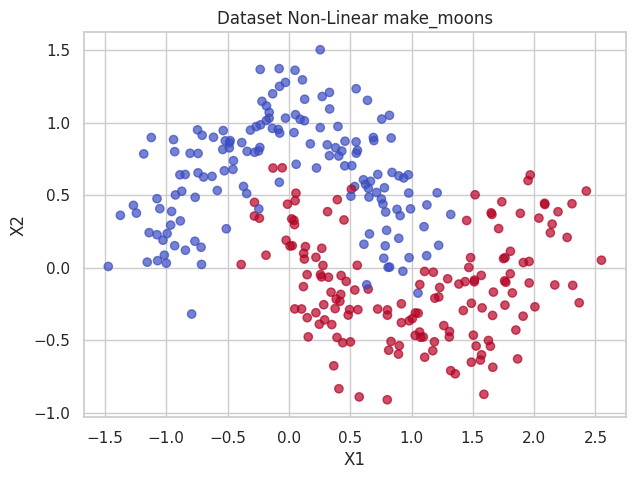

In [2]:
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", alpha=0.7)
plt.title("Dataset Non-Linear make_moons")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


## 3. Neural Network Sederhana


Akurasi pada data uji: 0.417
              precision    recall  f1-score   support

           0       0.22      0.07      0.10        30
           1       0.45      0.77      0.57        30

    accuracy                           0.42        60
   macro avg       0.34      0.42      0.34        60
weighted avg       0.34      0.42      0.34        60



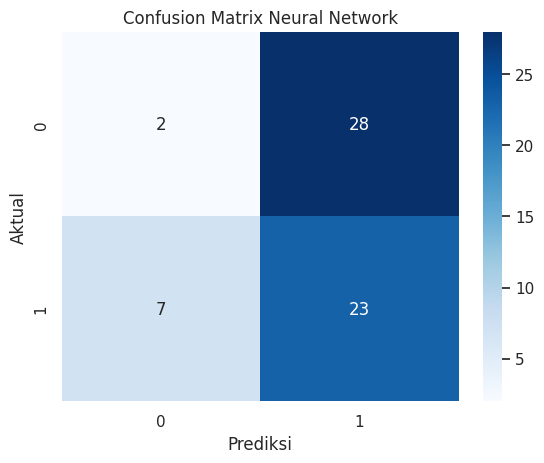

In [3]:
model = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=15
)

model.fit(X_tr, y_tr)
y_pred = model.predict(X_te)
y_prob = model.predict_proba(X_te)[:, 1]

acc = accuracy_score(y_te, y_pred)
print(f"Akurasi pada data uji: {acc:.3f}")
print(classification_report(y_te, y_pred))

cm = confusion_matrix(y_te, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix Neural Network")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

## 4. Kurva Pembelajaran


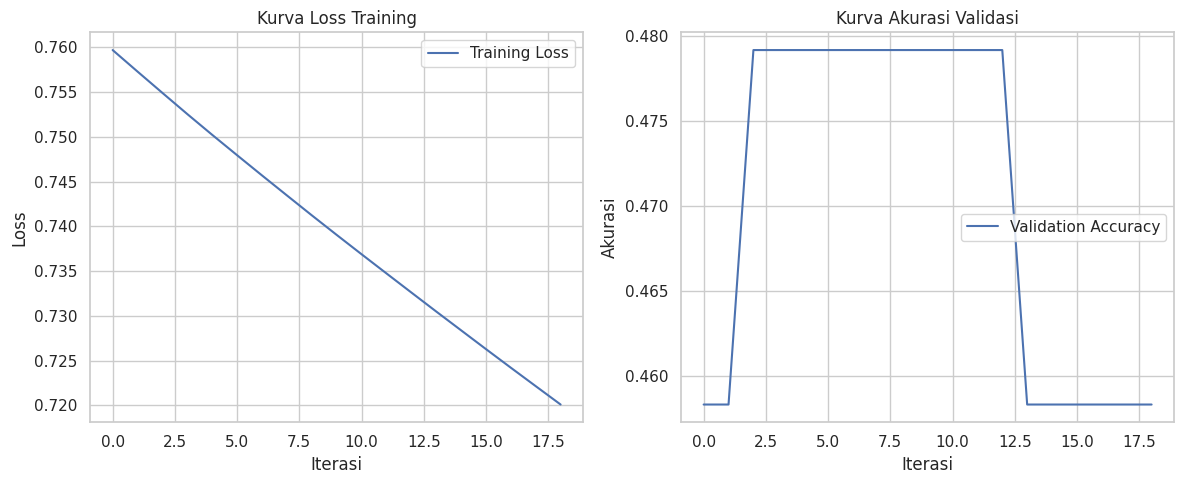

In [4]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(model.loss_curve_, label="Training Loss")
plt.title("Kurva Loss Training")
plt.xlabel("Iterasi")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
if hasattr(model, "validation_scores_") and model.validation_scores_ is not None:
    plt.plot(model.validation_scores_, label="Validation Accuracy")
    plt.title("Kurva Akurasi Validasi")
    plt.xlabel("Iterasi")
    plt.ylabel("Akurasi")
    plt.legend()
else:
    plt.text(0.5, 0.5, "Validation score tidak tersedia", ha="center")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 5. Dataset Ulasan Produk dan TF-IDF


In [5]:
ulasan = [
    "Barangnya bagus banget, pengiriman cepat",
    "Kualitas jelek, tidak sesuai deskripsi",
    "Sangat puas, akan beli lagi",
    "Kecewa, barang rusak saat sampai",
    "Recommended, harga sesuai kualitas",
    "Buruk sekali, tidak sesuai ekspektasi",
    "Produk original dan berfungsi dengan baik",
    "Pengiriman lama dan kemasan penyok",
    "Pelayanan ramah dan respon cepat",
    "Barang cacat, saya sangat kecewa",
    "Kualitas mantap dan harga terjangkau",
    "Tidak awet, baru dipakai sudah rusak",
    "Sesuai pesanan dan sangat memuaskan",
    "Warna berbeda dari foto produk",
    "Seller amanah, barang cepat sampai",
    "Produk tidak berfungsi sama sekali",
    "Packing rapi dan barang bagus",
    "Saya menyesal membeli produk ini",
    "Harga murah tapi kualitas tetap bagus",
    "Barang palsu dan mengecewakan",
    "Pengalaman belanja sangat menyenangkan",
    "Respon penjual lambat dan tidak membantu",
    "Produk nyaman digunakan sehari-hari",
    "Kualitas bahan buruk dan mudah rusak",
    "Sangat direkomendasikan untuk dibeli",
    "Barang tidak sesuai ukuran yang dipesan",
    "Pengiriman cepat, produk sesuai harapan",
    "Sangat buruk, tidak akan beli lagi",
    "Desain bagus dan performa memuaskan",
    "Paket datang terlambat dan rusak",
    "Barang berfungsi normal dan memuaskan",
    "Kualitas mengecewakan untuk harga segini",
    "Produk bagus, cocok untuk kebutuhan saya",
    "Tidak sesuai deskripsi, sangat kecewa",
    "Penjual cepat merespon dan membantu",
    "Barang kurang bagus dan tidak tahan lama",
    "Suka sekali dengan kualitas produknya",
    "Produk gagal digunakan sejak pertama dibuka",
    "Mantap, kualitas sesuai dengan harga",
    "Pelayanan buruk dan barang tidak layak"
]

label = [1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,
         1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0]

df_ulasan = pd.DataFrame({"ulasan": ulasan, "label": label})
display(df_ulasan.head())
display(df_ulasan["label"].value_counts())

tfidf = TfidfVectorizer(lowercase=True, max_features=100, ngram_range=(1, 2))
X_text = tfidf.fit_transform(df_ulasan["ulasan"])
y_text = df_ulasan["label"]

print("Shape TF-IDF:", X_text.shape)
print("Contoh fitur:", tfidf.get_feature_names_out()[:20])


,ulasan,label
0,"Barangnya bagus banget, pengiriman cepat",1
1,"Kualitas jelek, tidak sesuai deskripsi",0
2,"Sangat puas, akan beli lagi",1
3,"Kecewa, barang rusak saat sampai",0
4,"Recommended, harga sesuai kualitas",1


label
1    20
0    20
Name: count, dtype: int64

Shape TF-IDF: (40, 100)
Contoh fitur: ['akan' 'akan beli' 'amanah' 'amanah barang' 'awet' 'awet baru' 'bagus'
 'bagus banget' 'bagus cocok' 'bagus dan' 'bahan' 'bahan buruk' 'baik'
 'banget' 'banget pengiriman' 'barang' 'barang bagus' 'barang berfungsi'
 'barang cacat' 'barang cepat']


## 6. Logistic Regression untuk Analisis Sentimen


Akurasi model sentimen: 0.75
              precision    recall  f1-score   support

     Negatif       0.67      1.00      0.80         4
     Positif       1.00      0.50      0.67         4

    accuracy                           0.75         8
   macro avg       0.83      0.75      0.73         8
weighted avg       0.83      0.75      0.73         8



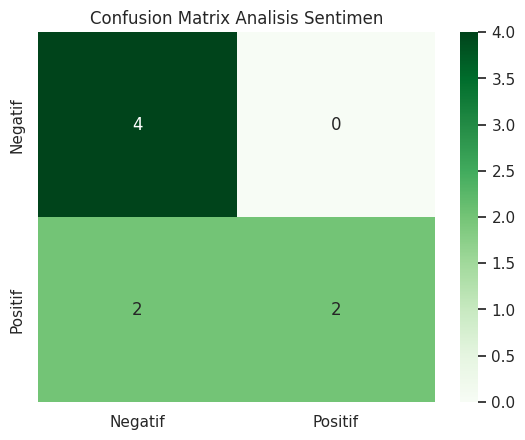

,kalimat,prediksi
0,Pelayanan sangat memuaskan dan ramah,Positif
1,Barang rusak dan kualitasnya sangat buruk,Negatif
2,"Produk bagus, sesuai harapan saya",Positif
3,Saya kecewa karena barang tidak sesuai,Negatif


In [6]:
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    X_text, y_text, test_size=0.2, random_state=42, stratify=y_text
)

model_sentimen = LogisticRegression(max_iter=1000)
model_sentimen.fit(Xt_tr, yt_tr)

pred_sentimen = model_sentimen.predict(Xt_te)

print("Akurasi model sentimen:", round(accuracy_score(yt_te, pred_sentimen), 3))
print(classification_report(yt_te, pred_sentimen, target_names=["Negatif", "Positif"]))

cm_sentimen = confusion_matrix(yt_te, pred_sentimen)
sns.heatmap(cm_sentimen, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Negatif", "Positif"],
            yticklabels=["Negatif", "Positif"])
plt.title("Confusion Matrix Analisis Sentimen")
plt.show()

kalimat_baru = [
    "Pelayanan sangat memuaskan dan ramah",
    "Barang rusak dan kualitasnya sangat buruk",
    "Produk bagus, sesuai harapan saya",
    "Saya kecewa karena barang tidak sesuai"
]

pred_baru = model_sentimen.predict(tfidf.transform(kalimat_baru))

hasil_prediksi = pd.DataFrame({
    "kalimat": kalimat_baru,
    "prediksi": ["Positif" if p == 1 else "Negatif" for p in pred_baru]
})

display(hasil_prediksi)


## Kesimpulan

Saya mempelajari Deep Learning dan NLP dasar. Temuan utama adalah Neural Network dapat menangani pola non-linear pada make_moons, sedangkan TF-IDF dan Logistic Regression dapat digunakan sebagai baseline analisis sentimen. Keterbatasannya, dataset ulasan masih sintetis dan ukurannya kecil.
